# Clustering No Supervisado — Hey Banco Datathon 2026

**Input:** `master_features_clean.csv` (15,025 usuarios × ~138 columnas) generado por el notebook de feature engineering.

**Pipeline:**
1. Carga y selección de features para clustering
2. Escalado con `RobustScaler` (tolerante a outliers)
3. **UMAP** para reducción dimensional (138D → 8D)
4. **HDBSCAN** para clustering basado en densidad
5. Perfilamiento de cada cluster en lenguaje de negocio
6. Visualizaciones para el pitch (UMAP 2D, heatmaps, radar charts)
7. Tabla maestra con `cluster_id` por usuario para la demo

**Decisiones técnicas clave:**
- **Por qué UMAP, no PCA:** preserva estructura local (clusters), no solo varianza global.
- **Por qué HDBSCAN, no K-means:** no pide número de clusters de antemano, tolera ruido (`-1`), detecta clusters de densidad variable. Mucho más realista para datos bancarios.
- **Por qué RobustScaler, no StandardScaler:** los montos tienen outliers extremos; RobustScaler usa mediana + IQR en lugar de media + std, evitando que un usuario millonario domine el scaling.

---
## 1. Setup

In [8]:
# Si falta alguna librería:
# !pip install umap-learn hdbscan plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
import umap
import hdbscan

# Estética
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR = '../data'
RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


---
## 2. Carga del feature store

In [9]:
master = pd.read_csv(f'{DATA_DIR}/master_features_clean.csv')
print(f'Master features: {master.shape}')
print(f'Columnas por bloque:')
for prefix in ['cli_', 'prod_', 'cred_', 'inv_', 'tx_', 'flag_']:
    n = len([c for c in master.columns if c.startswith(prefix)])
    print(f'  {prefix:8s}: {n:3d}')

Master features: (15025, 138)
Columnas por bloque:
  cli_    :  28
  prod_   :  23
  cred_   :  10
  inv_    :   2
  tx_     :  71
  flag_   :   3


---
## 3. Selección de features para clustering

Excluimos:
- `user_id` (identificador)
- Categóricas string como `cli_estado`, `cli_ciudad` (alta cardinalidad, requeriría target encoding que no tenemos)
- Bandas categóricas como `cli_buro_band` (ya tenemos `cli_score_buro` numérico)

Incluimos todas las numéricas + booleanas.

In [10]:
# Columnas a ignorar en clustering
ignore = [
    'user_id',
    'cli_sexo', 'cli_estado', 'cli_ciudad', 'cli_nivel_educativo',
    'cli_ocupacion', 'cli_canal_apertura', 'cli_preferencia_canal',
    'cli_idioma', 'cli_buro_band', 'cli_edad_band'
]

# Selección de features
num_cols = [c for c in master.select_dtypes(include=[np.number]).columns if c not in ignore]
bool_cols = [c for c in master.select_dtypes(include=['bool']).columns if c not in ignore]
feat_cols = num_cols + bool_cols

print(f'Features para clustering: {len(feat_cols)}')
print(f'  Numéricas: {len(num_cols)}')
print(f'  Booleanas: {len(bool_cols)}')

X = master[feat_cols].astype(float).fillna(0)
print(f'\nMatriz X: {X.shape}')
print(f'NaN restantes: {X.isna().sum().sum()}')

Features para clustering: 127
  Numéricas: 121
  Booleanas: 6

Matriz X: (15025, 127)
NaN restantes: 0


---
## 4. Escalado robusto

**RobustScaler** centra con mediana y escala con IQR. Resultado: `(x - mediana) / IQR`. Las features %  ya están en [0,1] y casi no se mueven; las de monto (con outliers) se escalan sin que un usuario millonario distorsione todo.

**Clip a ±10:** previene que valores extremos sigan dominando UMAP. La mayoría de features escaladas caen en [-3, 3].

In [11]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.clip(X_scaled, -10, 10)

print(f'X escalado: {X_scaled.shape}')
print(f'Rango: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')
print(f'Media: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}')

X escalado: (15025, 127)
Rango: [-10.00, 10.00]
Media: 0.2053, Std: 1.0548


---
## 5. UMAP — Reducción dimensional

**Por qué 8 componentes:**
- Suficientes para preservar estructura compleja
- Pocas para que HDBSCAN funcione bien (en >15D la maldición dimensional empieza a romper densidad)

**Hiperparámetros:**
- `n_neighbors=30`: balance entre estructura local vs global. Más alto = clusters más globales.
- `min_dist=0.0`: clusters más compactos (mejor para HDBSCAN).
- `random_state=42`: reproducibilidad. Sin esto cada corrida da clusters distintos.

**Tiempo:** ~1-2 min en CPU normal con 15k filas.

In [12]:
import time

print('Ejecutando UMAP (reducción a 8D para clustering)...')
t0 = time.time()
reducer_8d = umap.UMAP(
    n_neighbors=30,
    n_components=8,
    min_dist=0.0,
    metric='euclidean',
    random_state=RANDOM_STATE,
    verbose=False
)
X_umap_8d = reducer_8d.fit_transform(X_scaled)
print(f'  Listo: {time.time()-t0:.1f}s. Shape: {X_umap_8d.shape}')

print('\nEjecutando UMAP 2D (solo para visualización)...')
t0 = time.time()
reducer_2d = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,  # un poco más para que se vean los clusters
    metric='euclidean',
    random_state=RANDOM_STATE,
    verbose=False
)
X_umap_2d = reducer_2d.fit_transform(X_scaled)
print(f'  Listo: {time.time()-t0:.1f}s. Shape: {X_umap_2d.shape}')

Ejecutando UMAP (reducción a 8D para clustering)...
  Listo: 9.0s. Shape: (15025, 8)

Ejecutando UMAP 2D (solo para visualización)...
  Listo: 8.5s. Shape: (15025, 2)


---
## 6. HDBSCAN — Clustering

**Hiperparámetros:**
- `min_cluster_size=200`: con 15k usuarios, 200 (~1.3%) es un piso razonable para que un cluster sea "accionable". Si baja a 50, sale demasiada granularidad inservible para negocio.
- `min_samples=30`: qué tan conservador es el algoritmo al definir núcleo de densidad. Mayor = más puntos clasificados como ruido.
- `cluster_selection_method='eom'` (Excess of Mass): produce clusters más balanceados.

**Cluster `-1`:** usuarios que HDBSCAN no clasifica en ningún cluster ("ruido"). NO es un error — son usuarios atípicos. Para el pitch los pueden mostrar como un segmento aparte llamado "perfiles únicos" o tratarlos como caso de revisión manual.

In [13]:
print('Ejecutando HDBSCAN...')
t0 = time.time()
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=30,
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(X_umap_8d)
print(f'  Listo: {time.time()-t0:.1f}s')

# Resumen de clusters encontrados
unique, counts = np.unique(labels, return_counts=True)
n_clusters = len(unique) - (1 if -1 in unique else 0)
n_noise = (labels == -1).sum()

print(f'\n📊 Resumen:')
print(f'  Clusters identificados: {n_clusters}')
print(f'  Usuarios en ruido (-1): {n_noise:,} ({100*n_noise/len(labels):.1f}%)')
print(f'\nDistribución:')
for u, c in zip(unique, counts):
    label = '🔸 Ruido' if u == -1 else f'📍 Cluster {u}'
    print(f'  {label}: {c:>5,} usuarios ({100*c/len(labels):>5.1f}%)')

# Asignar al master
master['cluster_id'] = labels

Ejecutando HDBSCAN...
  Listo: 0.3s

📊 Resumen:
  Clusters identificados: 17
  Usuarios en ruido (-1): 95 (0.6%)

Distribución:
  🔸 Ruido:    95 usuarios (  0.6%)
  📍 Cluster 0:   525 usuarios (  3.5%)
  📍 Cluster 1:   294 usuarios (  2.0%)
  📍 Cluster 2: 1,939 usuarios ( 12.9%)
  📍 Cluster 3:   527 usuarios (  3.5%)
  📍 Cluster 4: 1,869 usuarios ( 12.4%)
  📍 Cluster 5:   535 usuarios (  3.6%)
  📍 Cluster 6:   822 usuarios (  5.5%)
  📍 Cluster 7: 1,130 usuarios (  7.5%)
  📍 Cluster 8:   676 usuarios (  4.5%)
  📍 Cluster 9:   273 usuarios (  1.8%)
  📍 Cluster 10:   395 usuarios (  2.6%)
  📍 Cluster 11: 1,679 usuarios ( 11.2%)
  📍 Cluster 12: 1,078 usuarios (  7.2%)
  📍 Cluster 13:   762 usuarios (  5.1%)
  📍 Cluster 14: 1,395 usuarios (  9.3%)
  📍 Cluster 15:   555 usuarios (  3.7%)
  📍 Cluster 16:   476 usuarios (  3.2%)


### 6.1 Si no estás contento con los resultados

**Reglas de pulgar para ajustar:**

| Síntoma | Ajuste |
|---|---|
| Demasiado ruido (>20%) | Bajar `min_samples` (de 30 a 15) |
| Pocos clusters (1-2) | Bajar `min_cluster_size` (de 200 a 100) |
| Demasiados clusters (>15) | Subir `min_cluster_size` (de 200 a 400) |
| Clusters poco compactos | Bajar `n_neighbors` en UMAP (de 30 a 15) |
| Clusters muy globales | Subir `n_neighbors` en UMAP (de 30 a 50) |

Para tu pitch lo ideal son **5-10 clusters** + algo de ruido. Si tienes 4, los segmentos son demasiado generales para storytelling de negocio. Si tienes 20, no se pueden defender uno por uno.

---
## 7. Visualización: UMAP 2D coloreado por cluster

**Esta es LA gráfica del pitch.** Si se ve buena estructura (clusters bien separados visualmente), tienes oro. Si se ve manchita uniforme, hay que ajustar.

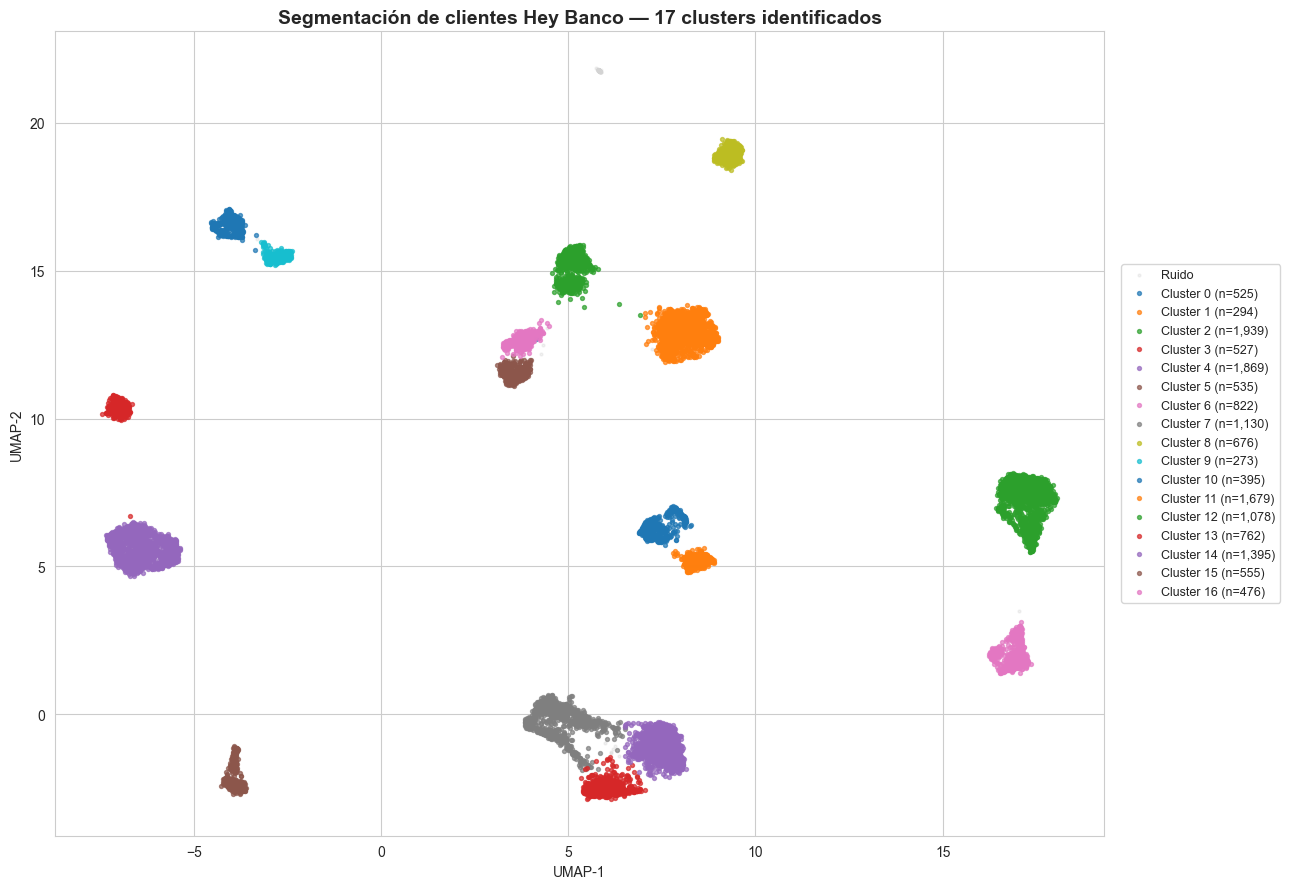

In [14]:
fig, ax = plt.subplots(figsize=(13, 9))

# Plotear ruido primero en gris (queda atrás)
noise_mask = labels == -1
ax.scatter(X_umap_2d[noise_mask, 0], X_umap_2d[noise_mask, 1],
           c='lightgray', s=4, alpha=0.3, label='Ruido')

# Plotear cada cluster con color distinto
palette = sns.color_palette('tab10', n_clusters)
for i, cluster_id in enumerate(sorted([u for u in unique if u != -1])):
    mask = labels == cluster_id
    ax.scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
               c=[palette[i]], s=8, alpha=0.7,
               label=f'Cluster {cluster_id} (n={mask.sum():,})')

ax.set_title(f'Segmentación de clientes Hey Banco — {n_clusters} clusters identificados',
             fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/clusters_umap_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Perfilamiento de clusters (la parte de negocio)

Para cada cluster identificamos:
1. **Tamaño** (cuántos usuarios y % de la base)
2. **Features distintivas** (qué los hace únicos vs. el promedio global)
3. **Etiqueta de negocio** (interpretación humana)

In [15]:
# Solo features numéricas/booleanas para perfilar (excluir el cluster_id mismo)
perfil_cols = [c for c in feat_cols if c != 'cluster_id']

# Promedio global (referencia)
global_mean = master[perfil_cols].mean()

# Promedio por cluster
cluster_means = master.groupby('cluster_id')[perfil_cols].mean()

# Ratio cluster/global: cuánto se desvía cada cluster del promedio
# (>1 = sobre el promedio, <1 = bajo el promedio)
ratio = cluster_means.div(global_mean.replace(0, np.nan)).fillna(0)

print(f'Tabla de medias por cluster: {cluster_means.shape}')
print(f'Tabla de ratios cluster/global: {ratio.shape}')

Tabla de medias por cluster: (18, 127)
Tabla de ratios cluster/global: (18, 127)


In [16]:
def describir_cluster(cluster_id, top_n=10):
    """Para un cluster dado, muestra sus features más distintivas."""
    print(f'\n{"="*70}')
    if cluster_id == -1:
        print(f'🔸 RUIDO — usuarios sin cluster claro')
    else:
        print(f'📍 CLUSTER {cluster_id}')
    n_users = (master['cluster_id'] == cluster_id).sum()
    print(f'   Tamaño: {n_users:,} usuarios ({100*n_users/len(master):.1f}% de la base)')
    print(f'{"="*70}')
    
    # Features con mayor desviación respecto al promedio global
    cluster_row = ratio.loc[cluster_id].dropna()
    # Filtrar features con varianza global despreciable
    valid = global_mean[global_mean.abs() > 0.01].index
    cluster_row = cluster_row[cluster_row.index.isin(valid)]
    
    # Top features SOBRE el promedio (lo distintivo positivo)
    top_high = cluster_row.sort_values(ascending=False).head(top_n)
    print(f'\n  ⬆️  Sobre el promedio global (más distintivas):')
    for feat, r in top_high.items():
        cluster_val = cluster_means.loc[cluster_id, feat]
        global_val = global_mean[feat]
        print(f'    {feat:40s} {cluster_val:>10.3f} vs global {global_val:>10.3f}  ({r:.1f}x)')
    
    # Top features BAJO el promedio
    top_low = cluster_row.sort_values(ascending=True).head(5)
    print(f'\n  ⬇️  Bajo el promedio global:')
    for feat, r in top_low.items():
        cluster_val = cluster_means.loc[cluster_id, feat]
        global_val = global_mean[feat]
        print(f'    {feat:40s} {cluster_val:>10.3f} vs global {global_val:>10.3f}  ({r:.1f}x)')

# Describir todos los clusters
for c in sorted(master['cluster_id'].unique()):
    describir_cluster(c, top_n=10)


🔸 RUIDO — usuarios sin cluster claro
   Tamaño: 95 usuarios (0.6% de la base)

  ⬆️  Sobre el promedio global (más distintivas):
    tx_frec_diaria                                6.942 vs global      0.202  (34.3x)
    cli_patron_atipico                            0.832 vs global      0.051  (16.4x)
    tx_pct_atipico                                0.832 vs global      0.051  (16.4x)
    cli_dormido_60d                               0.695 vs global      0.095  (7.3x)
    cli_dormido_30d                               0.832 vs global      0.117  (7.1x)
    tx_recencia_dias                            167.579 vs global     25.266  (6.6x)
    cli_dias_desde_login                         88.053 vs global     18.769  (4.7x)
    prod_tiene_tarjeta_credito_garantizada        0.137 vs global      0.040  (3.5x)
    prod_pct_cancelados                           0.319 vs global      0.097  (3.3x)
    tx_pct_canal_oxxo                             0.118 vs global      0.038  (3.1x)

  ⬇️  Bajo el pr

### 8.1 Resumen tabular para la presentación

Esta tabla es la base del slide "nuestros segmentos". La rellenas con etiquetas de negocio una vez interpretas los outputs anteriores.

In [17]:
resumen = []
for c in sorted(master['cluster_id'].unique()):
    if c == -1:
        continue
    sub = master[master['cluster_id'] == c]
    resumen.append({
        'cluster_id': c,
        'n_usuarios': len(sub),
        'pct_base': 100 * len(sub) / len(master),
        'edad_avg': sub['cli_edad'].mean(),
        'ingreso_avg': sub['cli_ingreso_mxn'].mean(),
        'es_hey_pro_pct': 100 * sub['cli_es_hey_pro'].mean(),
        'tx_monto_total_avg': sub['tx_monto_total'].mean(),
        'tx_n_total_avg': sub['tx_n_total'].mean(),
        'tx_pct_no_proc_avg': 100 * sub['tx_pct_no_procesada'].mean(),
        'tx_pct_canal_app_avg': 100 * sub['tx_pct_canal_app_total'].mean() if 'tx_pct_canal_app_total' in sub.columns else 0,
        'tiene_credito_pct': 100 * sub['flag_tiene_credito'].mean(),
        'tiene_inversion_pct': 100 * sub['flag_tiene_inversion'].mean(),
    })

resumen_df = pd.DataFrame(resumen).set_index('cluster_id')
print('Resumen de clusters (orientado a negocio):')
print(resumen_df.round(2).to_string())

Resumen de clusters (orientado a negocio):
            n_usuarios  pct_base  edad_avg  ingreso_avg  es_hey_pro_pct  tx_monto_total_avg  tx_n_total_avg  tx_pct_no_proc_avg  tx_pct_canal_app_avg  tiene_credito_pct  tiene_inversion_pct
cluster_id                                                                                                                                                                                   
0                  525     3.490    41.840   60,405.710           2.670         543,977.410          65.350               2.410                71.560             67.810                0.000
1                  294     1.960    42.180   55,969.390         100.000         572,422.680          68.010               2.450                71.230             68.030                0.000
2                 1939    12.910    24.830   18,309.180          81.280         203,072.190          70.800               2.480                71.150             99.950                0.000
3      

---
## 9. Visualizaciones para el pitch

### 9.1 Heatmap: clusters × features distintivas

Una sola gráfica que muestra de un vistazo qué define a cada cluster.

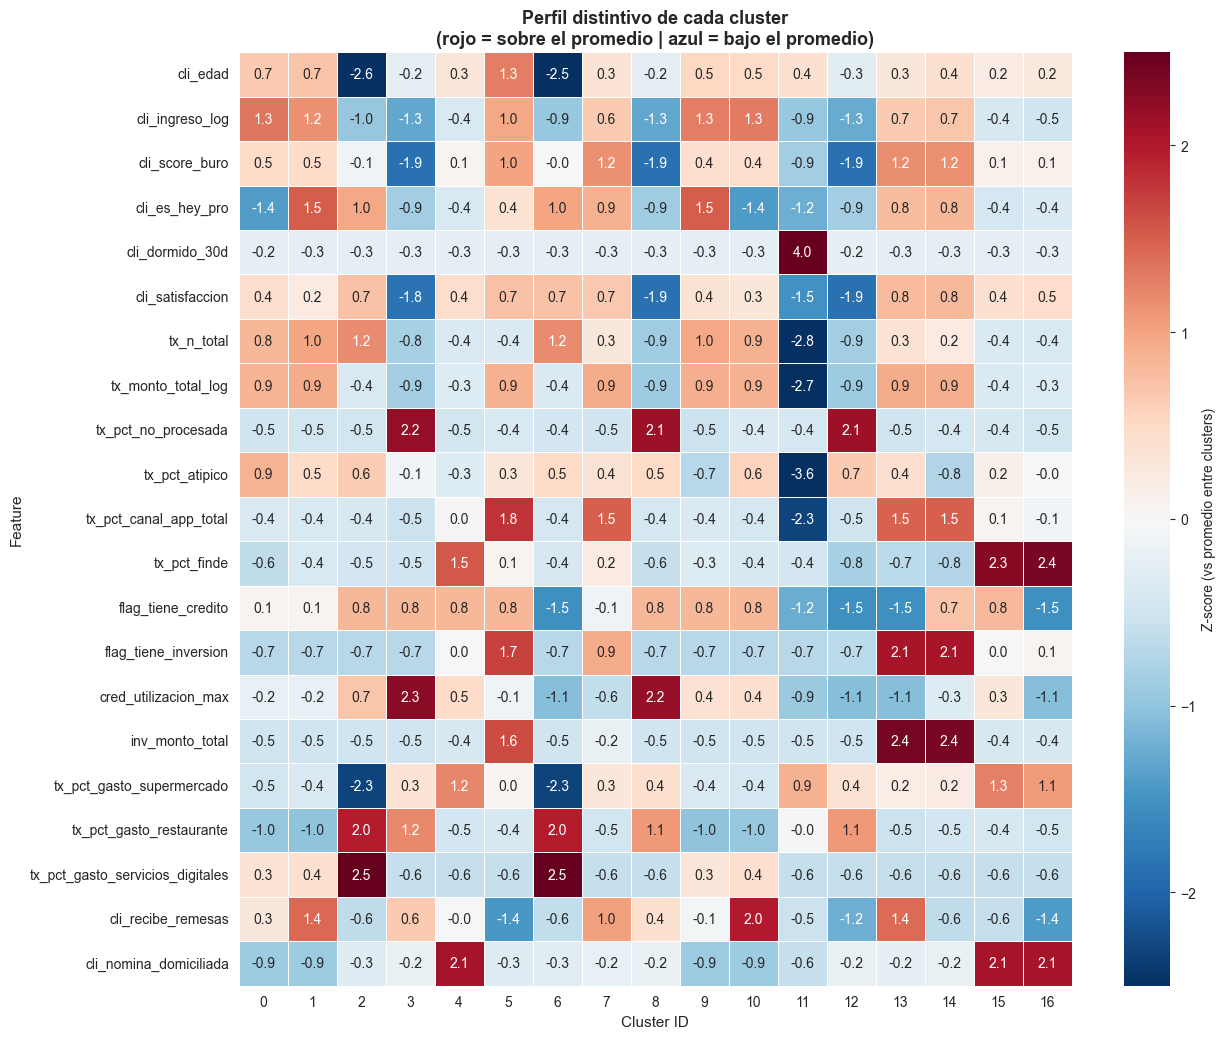

In [18]:
# Seleccionar features clave para el heatmap (las más interpretables para negocio)
features_pitch = [
    'cli_edad', 'cli_ingreso_log', 'cli_score_buro', 'cli_es_hey_pro',
    'cli_dormido_30d', 'cli_satisfaccion',
    'tx_n_total', 'tx_monto_total_log', 'tx_pct_no_procesada', 'tx_pct_atipico',
    'tx_pct_canal_app_total', 'tx_pct_finde',
    'flag_tiene_credito', 'flag_tiene_inversion',
    'cred_utilizacion_max', 'inv_monto_total',
    'tx_pct_gasto_supermercado', 'tx_pct_gasto_restaurante', 'tx_pct_gasto_servicios_digitales',
    'cli_recibe_remesas', 'cli_nomina_domiciliada',
]
features_pitch = [f for f in features_pitch if f in master.columns]

# Calcular Z-scores por feature (para que el heatmap sea comparable)
from scipy.stats import zscore
subset = master[master['cluster_id'] != -1].copy()
z_data = subset.groupby('cluster_id')[features_pitch].mean().apply(zscore)

fig, ax = plt.subplots(figsize=(13, max(5, 0.5 * len(features_pitch))))
sns.heatmap(z_data.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Z-score (vs promedio entre clusters)'},
            linewidths=0.5, ax=ax, vmin=-2.5, vmax=2.5)
ax.set_title('Perfil distintivo de cada cluster\n(rojo = sobre el promedio | azul = bajo el promedio)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/heatmap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Radar charts (un cluster por radar)

Visualización clásica de segmentación. Un radar por cluster, con las dimensiones más relevantes.

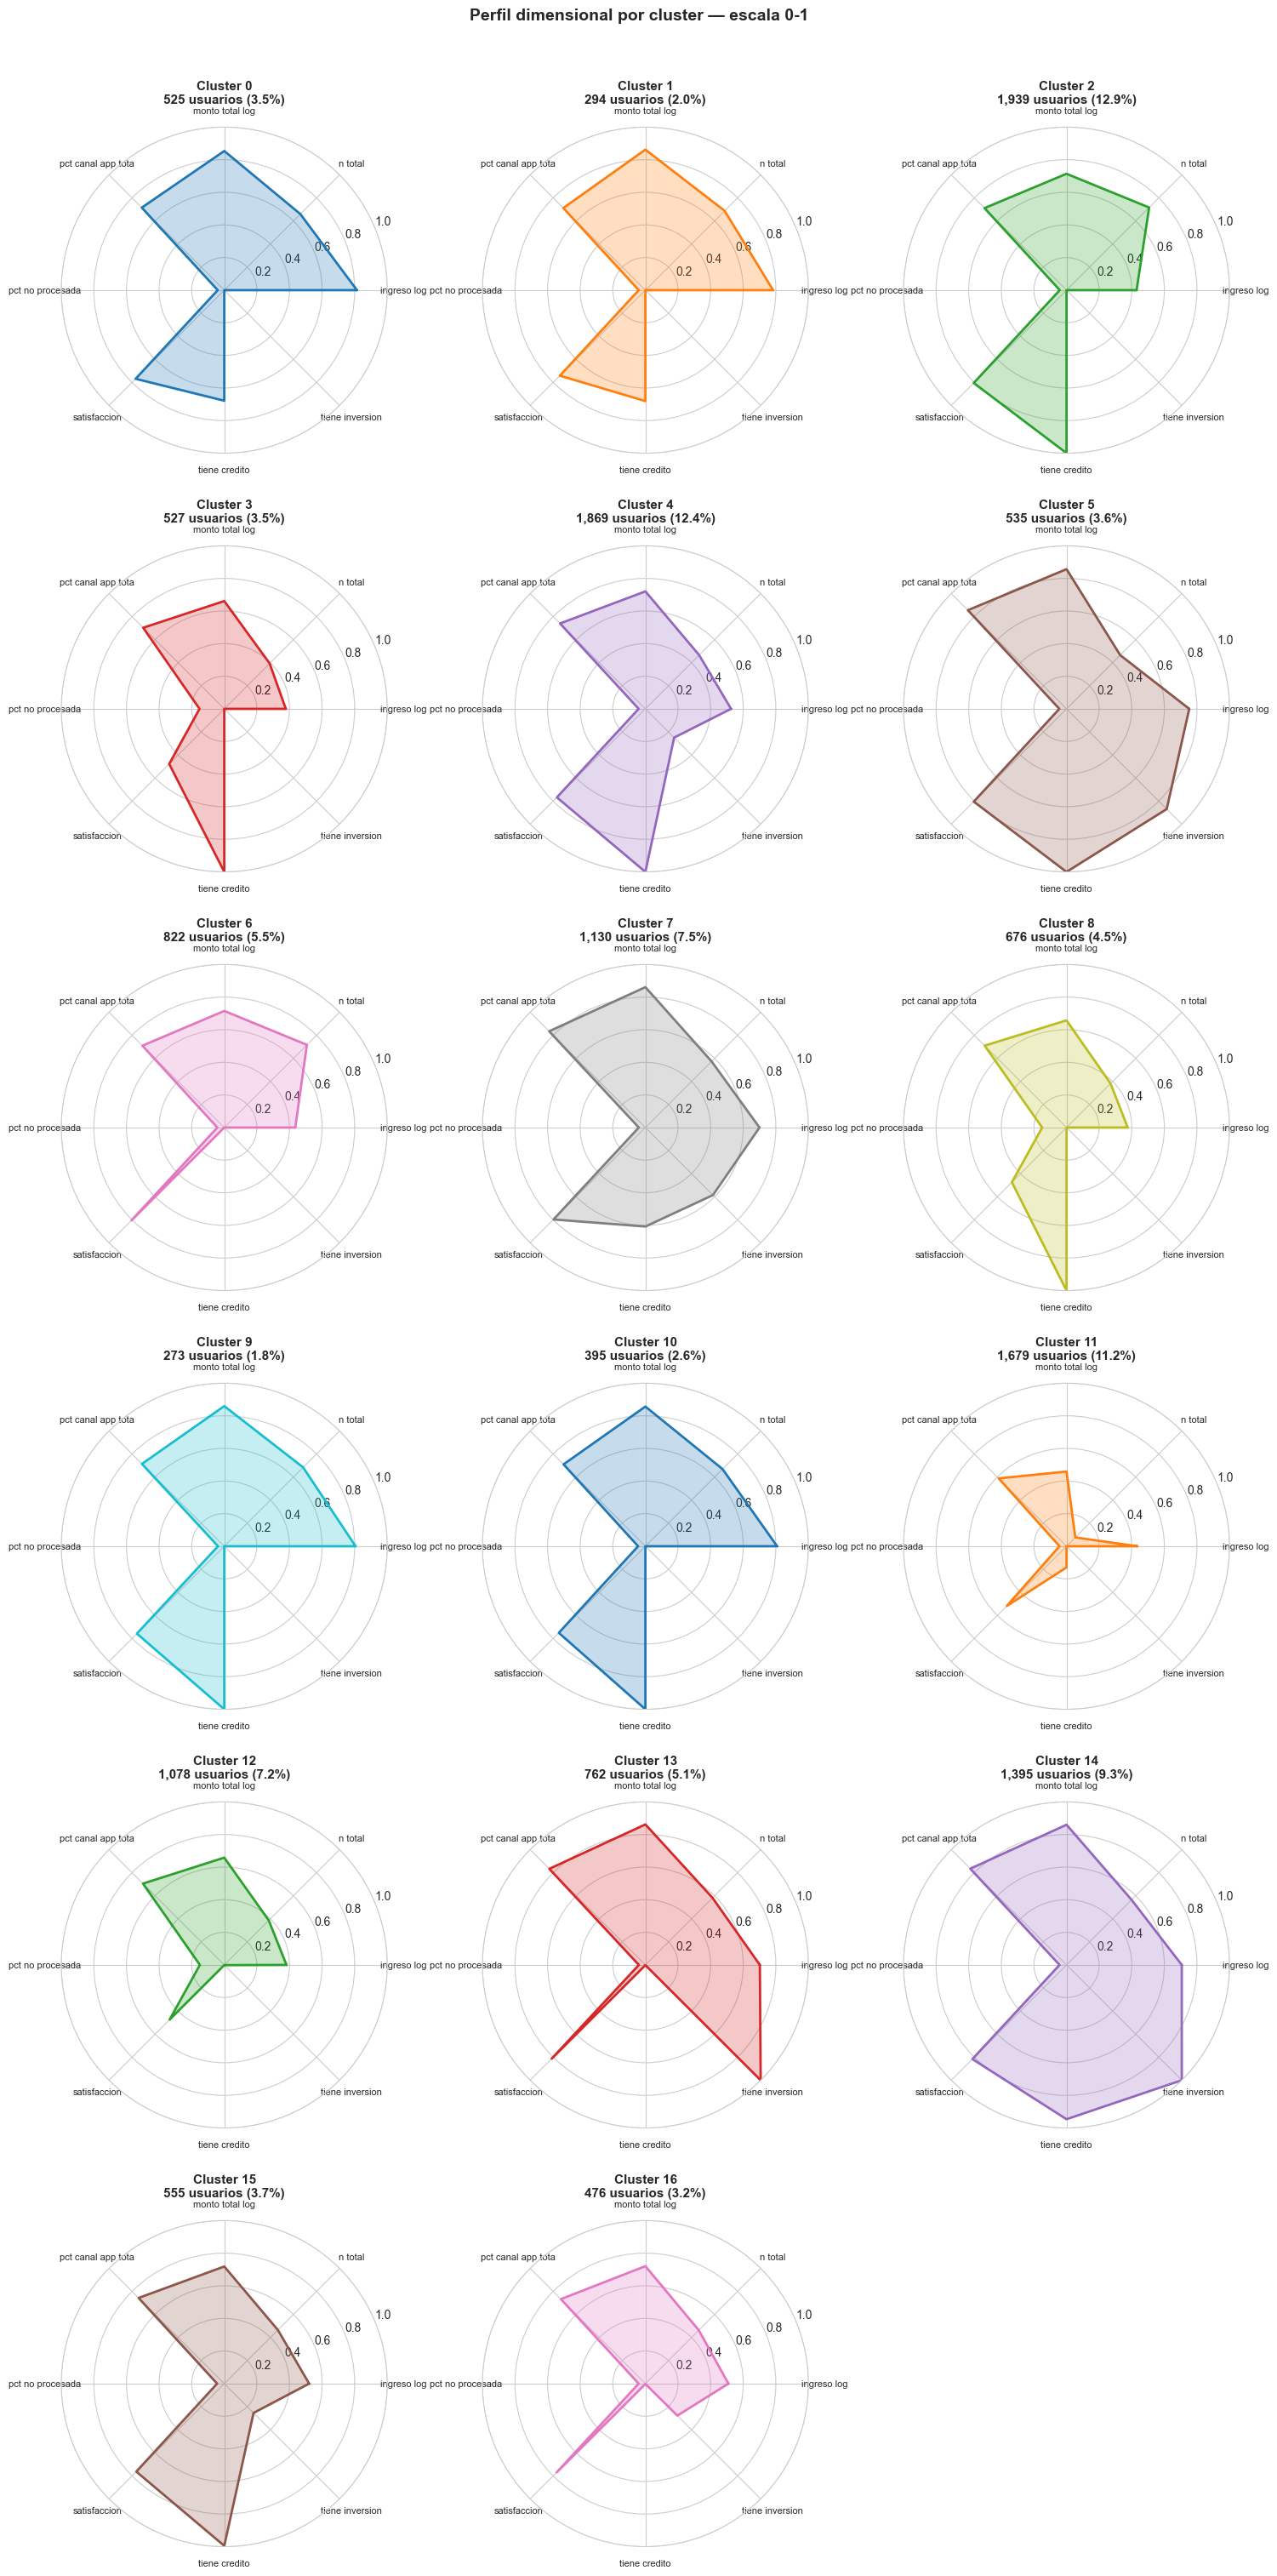

In [19]:
# Dimensiones para los radares (limitamos a 8 para legibilidad)
dim_radar = [
    'cli_ingreso_log',
    'tx_n_total',
    'tx_monto_total_log',
    'tx_pct_canal_app_total',
    'tx_pct_no_procesada',
    'cli_satisfaccion',
    'flag_tiene_credito',
    'flag_tiene_inversion',
]
dim_radar = [d for d in dim_radar if d in master.columns]

# Normalizar 0-1 sobre la base completa
subset_normalize = master[dim_radar].copy()
for col in dim_radar:
    mn, mx = subset_normalize[col].min(), subset_normalize[col].max()
    if mx > mn:
        subset_normalize[col] = (subset_normalize[col] - mn) / (mx - mn)
subset_normalize['cluster_id'] = master['cluster_id']

cluster_norm_means = subset_normalize[subset_normalize['cluster_id'] != -1].groupby('cluster_id').mean()

# Plot
n_clust = len(cluster_norm_means)
ncols = 3
nrows = (n_clust + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows),
                          subplot_kw=dict(projection='polar'))
axes = np.atleast_1d(axes).flatten()

angles = np.linspace(0, 2*np.pi, len(dim_radar), endpoint=False).tolist()
angles += angles[:1]

labels_short = [d.replace('cli_','').replace('tx_','').replace('flag_','').replace('_',' ')[:18]
                for d in dim_radar]

for i, (cid, row) in enumerate(cluster_norm_means.iterrows()):
    ax = axes[i]
    values = row[dim_radar].tolist()
    values += values[:1]
    ax.fill(angles, values, alpha=0.25, color=palette[i])
    ax.plot(angles, values, color=palette[i], linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, fontsize=8)
    ax.set_ylim(0, 1)
    n_size = (master['cluster_id'] == cid).sum()
    ax.set_title(f'Cluster {cid}\n{n_size:,} usuarios ({100*n_size/len(master):.1f}%)',
                  fontsize=11, fontweight='bold', pad=20)

# Ocultar axes sobrantes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Perfil dimensional por cluster — escala 0-1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/radares_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Bar chart: tamaño de clusters

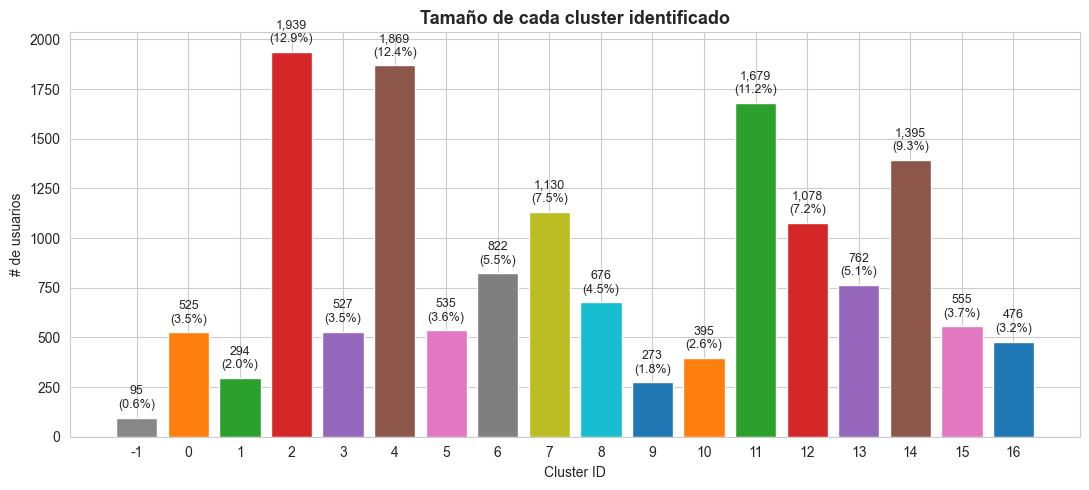

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
sizes = master['cluster_id'].value_counts().sort_index()

colors = ['#888888' if c == -1 else palette[i % len(palette)]
          for i, c in enumerate(sizes.index)]

bars = ax.bar(sizes.index.astype(str), sizes.values, color=colors, edgecolor='white')

for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({100*val/len(master):.1f}%)',
            ha='center', fontsize=9)

ax.set_title('Tamaño de cada cluster identificado', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('# de usuarios')
plt.tight_layout()
plt.savefig('../outputs/tamano_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Etiquetado en lenguaje de negocio

Aquí es donde el **equipo** (no el algoritmo) traduce los clusters a perfiles de negocio. Mira los outputs anteriores y rellena este diccionario.

**Plantilla de naming:** `[Adjetivo socioeconómico] [Adjetivo comportamental] [Sustantivo]`
- Ejemplos: "Premium Digital Frustrado", "Joven Aspiracional con Crédito", "Veterano Conservador"

In [21]:
# 👇 RELLENAR DESPUÉS DE INTERPRETAR LOS CLUSTERS 👇
etiquetas_clusters = {
    -1: 'Atípicos / Revisión Manual',
    # 0: 'Premium Digital',
    # 1: 'Joven Aspiracional',
    # 2: 'Stress Crediticio',
    # ...
}

# Si todavía no has etiquetado, llenar con default
for c in master['cluster_id'].unique():
    if c not in etiquetas_clusters:
        etiquetas_clusters[c] = f'Cluster_{c}_pendiente'

master['cluster_label'] = master['cluster_id'].map(etiquetas_clusters)

print('Etiquetas asignadas:')
print(master.groupby('cluster_label').size().sort_values(ascending=False).to_string())

Etiquetas asignadas:
cluster_label
Cluster_2_pendiente           1939
Cluster_4_pendiente           1869
Cluster_11_pendiente          1679
Cluster_14_pendiente          1395
Cluster_7_pendiente           1130
Cluster_12_pendiente          1078
Cluster_6_pendiente            822
Cluster_13_pendiente           762
Cluster_8_pendiente            676
Cluster_15_pendiente           555
Cluster_5_pendiente            535
Cluster_3_pendiente            527
Cluster_0_pendiente            525
Cluster_16_pendiente           476
Cluster_10_pendiente           395
Cluster_1_pendiente            294
Cluster_9_pendiente            273
Atípicos / Revisión Manual      95


---
## 11. Triggers de negocio basados en clusters

El paso clave que conecta clustering → acción → pitch. Para cada cluster, definir:
1. La **necesidad implícita** detectada
2. La **acción** del banco recomendada
3. La **métrica de éxito** esperada

**Triggers sugeridos** (validar contra los clusters reales que salgan):

In [22]:
# Plantilla de triggers — adaptar según los clusters que aparezcan
triggers_template = pd.DataFrame([
    {
        'trigger_id': 'T1_aumento_linea',
        'condicion': 'cred_flag_alta_utilizacion == 1 AND tx_motivo_limite_excedido > 0.3',
        'accion': 'Ofrecer aumento de línea de crédito o crédito personal',
        'segmento_objetivo': 'Clusters con alto stress crediticio',
        'metrica_exito': '% conversión a aumento aceptado',
    },
    {
        'trigger_id': 'T2_oferta_inversion',
        'condicion': 'flag_tiene_inversion == 0 AND tx_monto_total_log > p75 AND cli_dias_desde_login < 7',
        'accion': 'Push educativo + onboarding a inversion_hey',
        'segmento_objetivo': 'Clusters con saldos altos y sin inversión',
        'metrica_exito': '% conversión a inversion_hey en 30d',
    },
    {
        'trigger_id': 'T3_riesgo_churn',
        'condicion': 'cli_dormido_60d == 1 AND cli_satisfaccion < 6 AND tx_recencia_dias > 30',
        'accion': 'Outreach proactivo + survey + descuento personalizado',
        'segmento_objetivo': 'Clusters dormidos con baja satisfacción',
        'metrica_exito': '% reactivación 60d',
    },
    {
        'trigger_id': 'T4_hey_pro_subutilizado',
        'condicion': 'cli_es_hey_pro == 1 AND tx_cashback_total < p25_pro',
        'accion': 'Educación de beneficios + recordatorio de cashback',
        'segmento_objetivo': 'Hey Pro con baja generación de cashback',
        'metrica_exito': 'retención de Hey Pro + uso de cashback',
    },
    {
        'trigger_id': 'T5_remesa_sin_inversion',
        'condicion': 'cli_recibe_remesas == 1 AND flag_tiene_inversion == 0',
        'accion': 'Producto matching: micro-inversión automática',
        'segmento_objetivo': 'Receptores de remesas sin producto de inversión',
        'metrica_exito': '% activación micro-inversión',
    },
    {
        'trigger_id': 'T6_friccion_seguridad',
        'condicion': 'tx_motivo_tarjeta_bloqueada > 0.4 AND tx_pct_atipico > 0.05',
        'accion': 'Validación proactiva de identidad + ajuste de reglas',
        'segmento_objetivo': 'Clusters con mucha fricción de seguridad',
        'metrica_exito': 'NPS + reducción de bloqueos falsos',
    },
])

print('Triggers candidatos para el motor de necesidades:')
print(triggers_template.to_string(index=False))

triggers_template.to_csv('../outputs/triggers_negocio.csv', index=False)

Triggers candidatos para el motor de necesidades:
             trigger_id                                                                           condicion                                                 accion                               segmento_objetivo                          metrica_exito
       T1_aumento_linea                 cred_flag_alta_utilizacion == 1 AND tx_motivo_limite_excedido > 0.3 Ofrecer aumento de línea de crédito o crédito personal             Clusters con alto stress crediticio        % conversión a aumento aceptado
    T2_oferta_inversion flag_tiene_inversion == 0 AND tx_monto_total_log > p75 AND cli_dias_desde_login < 7            Push educativo + onboarding a inversion_hey       Clusters con saldos altos y sin inversión    % conversión a inversion_hey en 30d
        T3_riesgo_churn             cli_dormido_60d == 1 AND cli_satisfaccion < 6 AND tx_recencia_dias > 30  Outreach proactivo + survey + descuento personalizado         Clusters dormidos con baja sa

In [23]:
# Ejemplo: aplicar el trigger T1 a la base actual
p75_monto = master['tx_monto_total_log'].quantile(0.75)

# Trigger T1: alto stress crediticio
if 'cred_flag_alta_utilizacion' in master.columns and 'tx_motivo_limite_excedido' in master.columns:
    t1 = master[
        (master['cred_flag_alta_utilizacion'] == 1) &
        (master['tx_motivo_limite_excedido'] > 0.3)
    ]
    print(f'\nT1 (Aumento de línea): {len(t1):,} usuarios elegibles')
    print(f'  Distribución por cluster:')
    print(t1['cluster_id'].value_counts().to_string())

# Trigger T2: oferta de inversión
t2 = master[
    (master['flag_tiene_inversion'] == 0) &
    (master['tx_monto_total_log'] > p75_monto) &
    (master['cli_dias_desde_login'] < 7)
]
print(f'\nT2 (Oferta inversión): {len(t2):,} usuarios elegibles')
print(f'  Distribución por cluster:')
print(t2['cluster_id'].value_counts().to_string())


T1 (Aumento de línea): 139 usuarios elegibles
  Distribución por cluster:
cluster_id
8    75
3    64

T2 (Oferta inversión): 689 usuarios elegibles
  Distribución por cluster:
cluster_id
7     226
0     161
10    117
9      91
1      86
5       8


---
## 12. Export final

Tres archivos para que la persona de demo y la persona de pitch trabajen sin tener que re-correr clustering.

In [24]:
# 1. Master con cluster_id y cluster_label asignados
master.to_csv(f'{DATA_DIR}/master_with_clusters.csv', index=False)

# 2. Resumen de clusters (para el slide de segmentos del pitch)
resumen_df.to_csv(f'{DATA_DIR}/clusters_resumen.csv')

# 3. Tabla de medias por cluster (para el equipo que arma la demo)
cluster_means.to_csv(f'{DATA_DIR}/clusters_perfiles_full.csv')

# 4. Embeddings UMAP (para la demo en Streamlit, plotear punto del usuario)
umap_df = pd.DataFrame({
    'user_id': master['user_id'],
    'umap_x': X_umap_2d[:, 0],
    'umap_y': X_umap_2d[:, 1],
    'cluster_id': labels,
    'cluster_label': master['cluster_label'],
})
umap_df.to_csv(f'{DATA_DIR}/umap_coordinates.csv', index=False)

print('Archivos generados:')
print(f'  ../data/master_with_clusters.csv     ({master.shape})')
print(f'  ../data/clusters_resumen.csv         ({resumen_df.shape})')
print(f'  ../data/clusters_perfiles_full.csv   ({cluster_means.shape})')
print(f'  ../data/umap_coordinates.csv         ({umap_df.shape})')
print(f'  ../outputs/triggers_negocio.csv      ({triggers_template.shape})')

Archivos generados:
  ../data/master_with_clusters.csv     ((15025, 140))
  ../data/clusters_resumen.csv         ((17, 11))
  ../data/clusters_perfiles_full.csv   ((18, 127))
  ../data/umap_coordinates.csv         ((15025, 5))
  ../outputs/triggers_negocio.csv      ((6, 5))


---
## 13. Siguiente paso

1. **Persona NLP:** lee `master_with_clusters.csv`, genera tópicos Havi y los cruza con clusters → tabla `cluster × tópico` muestra qué *necesidades verbalizan* cada segmento.
2. **Persona demo:** consume `umap_coordinates.csv` + `master_with_clusters.csv` para Streamlit. Input = `user_id` → output = ficha de cluster + triggers activos.
3. **Persona pitch:** consume `clusters_resumen.csv`, `heatmap_clusters.png`, `radares_clusters.png`, `clusters_umap_2d.png` para los slides.

**Para defender en Q&A:**
- *"¿Por qué HDBSCAN y no K-means?"* — HDBSCAN no requiere asumir número de clusters; tolera ruido (clientes atípicos); detecta densidades variables — más realista en banca.
- *"¿Cómo validan los clusters sin ground truth?"* — silhouette score sobre el espacio UMAP; coherencia con interpretación de negocio; estabilidad ante perturbación de datos (bootstrap).
- *"¿Cómo se actualiza esto en producción?"* — `prediction_data=True` permite asignar nuevos usuarios a clusters existentes con `hdbscan.approximate_predict`. Re-entrenar el modelo cada 30 días.